# Lab 5.1: Convolutions

In this lab you will see how the 2D cross-correlation filter can act as a simple pattern recognizer or object detector.

In [35]:
![ -f cat.jpg ] || curl -sL -o cat.jpg "https://www.dropbox.com/scl/fi/vc3j08yctlosvpr57v2ot/cat.jpg?rlkey=nbgc9klg8wlgkfewk08ln72xf&dl=1"

In [36]:
from imageio.v3 import imread, imwrite
from skimage.transform import rescale
from scipy.ndimage import convolve, correlate
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
import numpy as np

### Exercises

1. Load the `cat.jpg` image, rescale it by 50%, and convert to grayscale as done in Notebook 5.1.

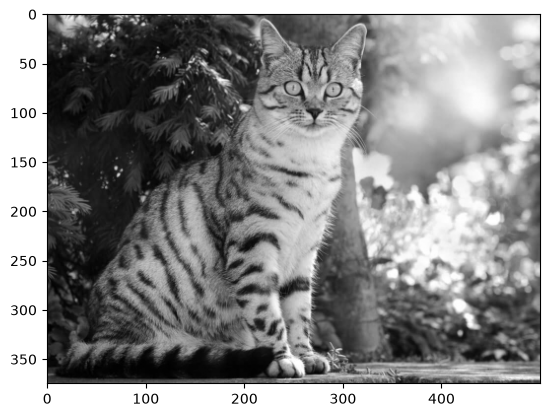

In [37]:
img = imread('cat.jpg')
img = rescale(img, 0.5, anti_aliasing=True, channel_axis=-1)
gray = rgb2gray(img)
plt.imshow(gray,cmap='gray')

2. These coordinates specify a box around the cat's face:

- Top, Left: (0,205)
- Bottom, Right: (128,325)

Crop the `gray` image to this box and show the result.  It should show just the cat's face.

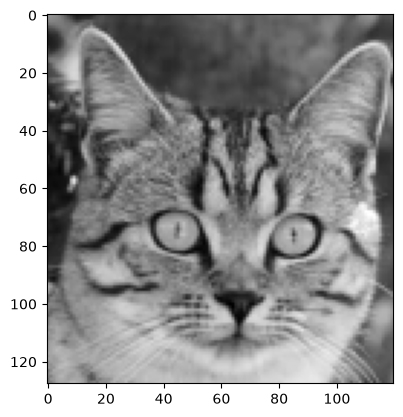

In [38]:
face = gray[0:128,205:325]
plt.imshow(face,cmap='gray')

3. To turn the cat face into a filter, subtract the mean from the cropped image.

Print out the mean of the filter to verify that it is zero.

In [39]:
filter = face - face.mean()
filter.mean()

np.float64(2.2204460492503132e-17)

4. Apply the cat face filter to the original `gray` image using cross-correlation and show the result.

You should see a bright spot at the location of middle of the cat's face.  Why?

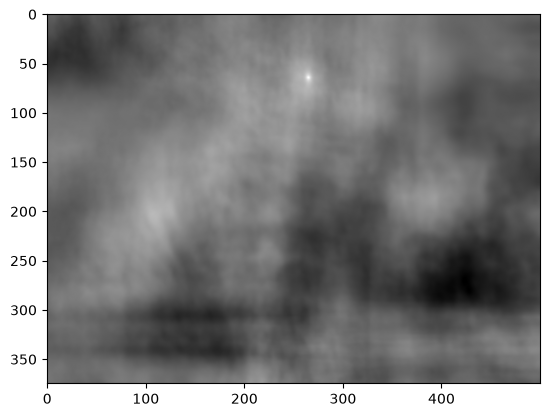

In [40]:
result = correlate(gray, filter)
plt.imshow(result, cmap='gray')

Because that is the point that the filter is constructed from, so it looks 1-1 at that location. It is the most similar it gets to the filter that is being applied over it.

5. Now let's crop one of the eyes and see how that well that works as an eye detector.

The left eye's coordinates:
- Top, Left: 68, 241
- Bottom, Right: 82, 259

Crop out the left eye, convert to a filter, and show the result of cross-correlation.

Does it detect both eyes well, or just the left eye?

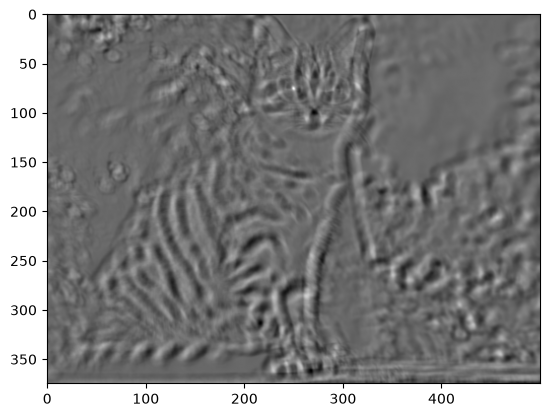

In [41]:
left_eye = gray[68:82,241:259]
left_eye_filter = left_eye - left_eye.mean()

le_result = correlate(gray, left_eye_filter)
plt.imshow(le_result, cmap='gray')

just does the left eye well

6. To improve the result of the eye detector, we can crop both eyes and average them together before creating the filter.

Here are the right eye coordinates:
- Top, Left: 70, 282
- Bottom, Right: 84, 300

Crop out the right eye, compute the average of the left eye and right eye crops, and then create the filter from that and show the result.

Does the averaged eye filter detect both eyes more effectively than the left eye filter?  Why?

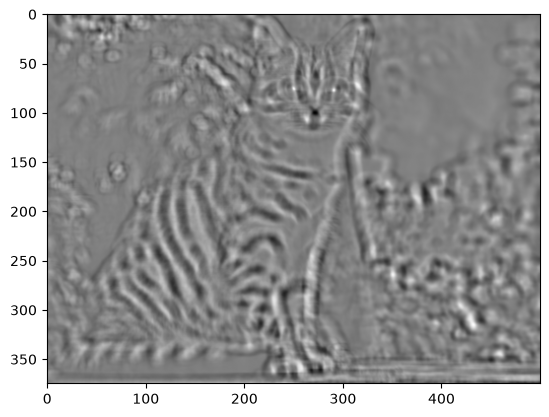

In [42]:
right_eye = gray[70:84, 282:300]

eyes = (left_eye + right_eye)/2

eyes_filter = eyes - eyes.mean()
eyes_result = correlate(gray, eyes_filter)
plt.imshow(eyes_result, cmap='gray')

Yes, it's pretty good, because it is learning more of the shape instead of what the left or right eye specifically looks like.
